In [82]:
import re
from collections import defaultdict
from pathlib import Path

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize

In [83]:
!pwd

/Users/neara_interview/Trace_projects/hens-hurricane/earth2studio/recipes/hens/notebooks


In [84]:
beryl_era5 = xr.open_dataset("../../../../data/beryl_outputs/beryl_era5.nc")

In [85]:
beryl_era5 = beryl_era5.isel(season=0).sel(time=slice("2024-07-05", "2024-07-15"))

In [86]:
beryl_era5 = beryl_era5[
    ['wind_speed_10m', 'mean_sea_level_pressure']
]

In [87]:
beryl_era5 = beryl_era5['wind_speed_10m'].sel(
    lon=slice(-95.8, -95.0),
    lat=slice(30.1, 29.5)
).mean(['lat', 'lon'])

In [88]:
output_dir = Path("../../../../data/beryl_outputs/houston")

# Fixed global member ranges for each checkpoint seed
seed_offsets = {
    12: 0,
    16: 10,
    17: 20,
    18: 30,
}

files_by_init = {}

for path in output_dir.glob("*.nc"):
    match = re.search(
        r"beryl-poc_(\d{4}-\d{2}-\d{2}T\d{2})_pkg_seed(\d+)\.nc$",
        path.name,
    )

    if match is None:
        continue

    init_time = match.group(1)
    seed = int(match.group(2))

    files_by_init.setdefault(init_time, []).append((seed, path))

all_initialisations = []

for init_time in sorted(files_by_init):
    checkpoint_datasets = []

    for seed, path in sorted(files_by_init[init_time]):
        ds = xr.open_dataset(path)

        n_members = ds.sizes["ensemble"]
        offset = seed_offsets[seed]

        ds = ds.assign_coords(
            ensemble=np.arange(offset, offset + n_members),
            seed=("ensemble", np.full(n_members, seed)),
        )

        checkpoint_datasets.append(ds)

    combined_init = xr.concat(
        checkpoint_datasets,
        dim="ensemble",
        coords="minimal",
        compat="override",
    )

    all_initialisations.append(combined_init)

tx = xr.concat(
    all_initialisations,
    dim="time",
    coords="minimal",
    compat="override"
)

In [89]:
print(tx)

<xarray.Dataset> Size: 140MB
Dimensions:    (ensemble: 40, time: 6, lead_time: 29, lat: 41, lon: 41)
Coordinates:
  * ensemble   (ensemble) int64 320B 0 1 2 3 4 5 6 7 ... 32 33 34 35 36 37 38 39
    seed       (ensemble) int64 320B 12 12 12 12 12 12 12 ... 18 18 18 18 18 18
  * time       (time) datetime64[ns] 48B 2024-07-05 ... 2024-07-08T12:00:00
  * lead_time  (lead_time) timedelta64[ns] 232B 0 days 00:00:00 ... 7 days 00...
  * lat        (lat) float64 328B 35.0 34.75 34.5 34.25 ... 25.5 25.25 25.0
  * lon        (lon) float64 328B 260.0 260.2 260.5 260.8 ... 269.5 269.8 270.0
Data variables:
    u10m       (ensemble, time, lead_time, lat, lon) float32 47MB -0.2894 ......
    v10m       (ensemble, time, lead_time, lat, lon) float32 47MB -1.026 ... ...
    msl        (ensemble, time, lead_time, lat, lon) float32 47MB 1.012e+05 ....


In [90]:
tx['w10m'] = np.sqrt(tx['u10m'] ** 2 + tx['v10m'] ** 2)

In [93]:
wind_mean.max()

<xarray.DataArray 'w10m' ()> Size: 8B
array(19.41271756)

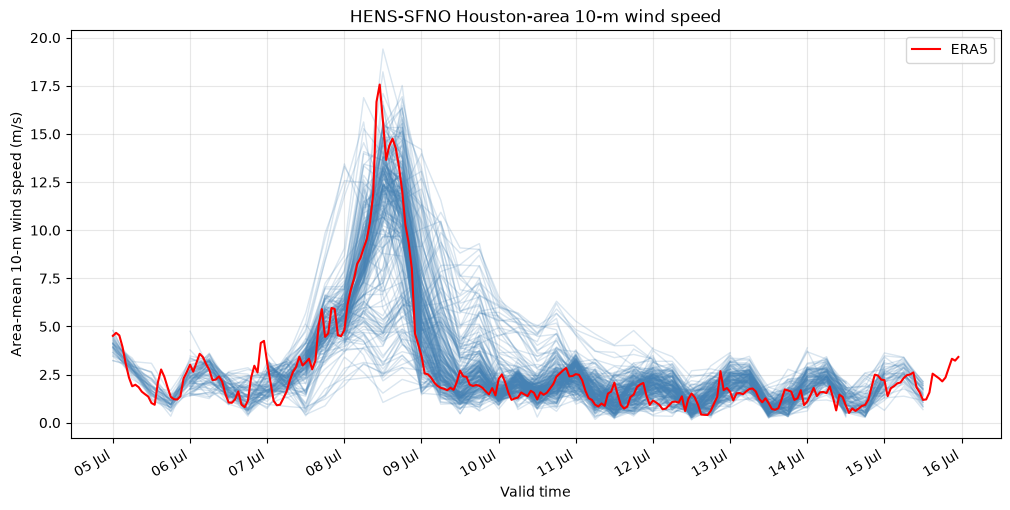

In [92]:
import numpy as np

# Houston metro bounding box
lat_min, lat_max = 29.5, 30.1
lon_min, lon_max = 264.2, 265.0  # -95.8 to -95.0 in 0–360 coordinates

# Select Houston region from the combined dataset
houston = tx["w10m"].sel(
    lat=slice(lat_max, lat_min),  # latitude is descending
    lon=slice(lon_min, lon_max),
)

# Cosine-latitude weights for an area-weighted mean
weights = np.cos(np.deg2rad(houston.lat))

wind_mean = (
    houston
    .weighted(weights)
    .mean(dim=("lat", "lon"))
    .compute()
)

# Plot each ensemble member and initialisation separately
fig, ax = plt.subplots(figsize=(12, 6))

for ensemble in wind_mean.ensemble.values:
    for init_time in wind_mean.time.values:

        wind_series = wind_mean.sel(
            ensemble=ensemble,
            time=init_time,
        )

        valid_time = init_time + wind_series.lead_time.values

        ax.plot(
            valid_time,
            wind_series.values,
            color="steelblue",
            alpha=0.2,
            linewidth=1,
        )

ax.plot(beryl_era5.time, beryl_era5.values, color="red", label="ERA5")

ax.set_xlabel("Valid time")
ax.set_ylabel("Area-mean 10-m wind speed (m/s)")
ax.set_title("HENS-SFNO Houston-area 10-m wind speed")
ax.grid(True, alpha=0.3)

ax.xaxis.set_major_locator(mdates.DayLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))

ax.legend()

fig.autofmt_xdate()
plt.show()

## Cyclone tracking

In [52]:
ibtracs = pd.read_csv(
    "../../../../data/beryl_outputs/ibtracs.NA.list.v04r01.csv",
    low_memory=False,
    skiprows=[1],
    keep_default_na=False,
    # parse_dates=True
    )

In [53]:
ibtracs = ibtracs[
    (ibtracs.BASIN == "NA") &
    (ibtracs.SEASON >= 1980)
].copy()

In [54]:
ibtracs['ISO_TIME'] = pd.to_datetime(ibtracs['ISO_TIME'])

In [55]:
cols = [
    "SID", "SEASON", "NAME", "ISO_TIME",
    "LAT", "LON", "USA_STATUS",
    # "USA_SSHS",
    "USA_WIND", "USA_PRES",
    # "USA_R34_NE", "USA_R34_SE", "USA_R34_SW", "USA_R34_NW",
    # "USA_R64_NE", "USA_R64_SE", "USA_R64_SW", "USA_R64_NW",
    # "DIST2LAND", "LANDFALL",
]

ibtracs = ibtracs[cols].copy()

In [57]:
gdf = gpd.GeoDataFrame(
    ibtracs.copy(),
    geometry=gpd.points_from_xy(
        ibtracs["LON"],
        ibtracs["LAT"]
    ),
    crs="EPSG:4326"
).to_crs("EPSG:5070")

In [58]:
print(gdf)

                  SID  SEASON     NAME            ISO_TIME   LAT   LON  \
85538   1980199N31284    1980  UNNAMED 1980-07-17 00:00:00  30.5 -76.5   
85539   1980199N31284    1980  UNNAMED 1980-07-17 03:00:00  30.3 -76.9   
85540   1980199N31284    1980  UNNAMED 1980-07-17 06:00:00  30.2 -77.2   
85541   1980199N31284    1980  UNNAMED 1980-07-17 09:00:00  30.1 -77.6   
85542   1980199N31284    1980  UNNAMED 1980-07-17 12:00:00  30.0 -78.0   
...               ...     ...      ...                 ...   ...   ...   
127111  2026199N26277    2026   BERTHA 2026-07-23 12:00:00  29.5 -92.6   
127112  2026199N26277    2026   BERTHA 2026-07-23 15:00:00  29.7 -93.2   
127113  2026199N26277    2026   BERTHA 2026-07-23 18:00:00  29.8 -93.9   
127114  2026199N26277    2026   BERTHA 2026-07-23 21:00:00  29.9 -94.5   
127115  2026199N26277    2026   BERTHA 2026-07-24 00:00:00  30.0 -95.2   

       USA_STATUS USA_WIND USA_PRES                         geometry  
85538          TD       20           POI

In [2]:
root = Path("../../../../data/beryl_outputs/cyclones")

# Group files by initialisation time
files_by_init = defaultdict(list)

for file in sorted(root.glob("**/*.nc")):
    match = re.search(
        r"tracks_pkg_(\d+)_(\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2})_batch_(\d+)\.nc$",
        file.name,
    )

    if match is None:
        # print("Skipped:", file)
        continue

    seed = int(match.group(1))
    init_time = match.group(2)
    batch = int(match.group(3))

    files_by_init[init_time].append((seed, batch, file))

# Combine batches for each initialisation
tracks_by_init = {}

for init_time, items in sorted(files_by_init.items()):
    arrays = []

    for seed, batch, file in sorted(items, key=lambda x: (x[0], x[1])):
        # print("Opening:", file)

        da = xr.open_dataarray(file)

        # Preserve the checkpoint seed
        da = da.assign_coords(
            seed=("ensemble", np.full(da.sizes["ensemble"], seed))
        )

        arrays.append(da)

    # Concatenate batch/member files
    tracks_by_init[init_time] = xr.concat(
        arrays,
        dim="ensemble",
        coords="minimal",
        compat="override",
    )

/var/folders/4w/jglrh5ks0m93wsr18jhkqvyr0000gn/T/ipykernel_29644/1414638791.py:41: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'path_id' ('path_id',) The recommendation is to set join explicitly for this case.
  tracks_by_init[init_time] = xr.concat(
/var/folders/4w/jglrh5ks0m93wsr18jhkqvyr0000gn/T/ipykernel_29644/1414638791.py:41: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'path_id' ('path_id',) The recommendation is to set join explicitly for this case.
  tracks_by_init[init_time] = xr.concat(
/var/folders

In [3]:
tracks_all = xr.concat(
    list(tracks_by_init.values()),
    dim="time",
    coords="minimal",
    compat="override",
)

/var/folders/4w/jglrh5ks0m93wsr18jhkqvyr0000gn/T/ipykernel_29644/2546155076.py:1: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'path_id' ('path_id',) The recommendation is to set join explicitly for this case.
  tracks_all = xr.concat(


In [4]:
print(tracks_all)

<xarray.DataArray (ensemble: 40, time: 6, path_id: 36, step: 29, variable: 4)> Size: 8MB
array([[[[[ 3.75742290e+01,  1.60996813e+02,  1.00696203e+05,
            1.83996906e+01],
          [            nan,             nan,             nan,
                       nan],
          [            nan,             nan,             nan,
                       nan],
          ...,
          [            nan,             nan,             nan,
                       nan],
          [            nan,             nan,             nan,
                       nan],
          [            nan,             nan,             nan,
                       nan]],

         [[ 3.45118497e+01,  3.58919533e+02,  1.00815781e+05,
            8.72760105e+00],
          [            nan,             nan,             nan,
                       nan],
          [            nan,             nan,             nan,
                       nan],
...
          [            nan,             nan,             nan,
         

(array([ 273., 1642., 3102., 2740., 1781., 1216.,  748.,  270.,   56.,
          11.]),
 array([ 1.19818377,  4.35237625,  7.50656872, 10.66076119, 13.81495366,
        16.96914613, 20.1233386 , 23.27753108, 26.43172355, 29.58591602,
        32.74010849]),
 <BarContainer object of 10 artists>)

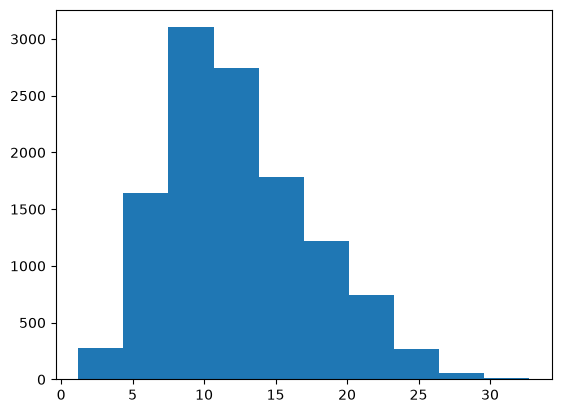

In [6]:
plt.hist(tracks_all.sel(variable="tcw10m").values.flatten())

(array([  18.,  103.,  227., 1175., 2219., 3074., 2560., 1906.,  458.,
          99.]),
 array([ 97241.28125   ,  97745.22265625,  98249.1640625 ,  98753.10546875,
         99257.046875  ,  99760.98828125, 100264.9296875 , 100768.87109375,
        101272.8125    , 101776.75390625, 102280.6953125 ]),
 <BarContainer object of 10 artists>)

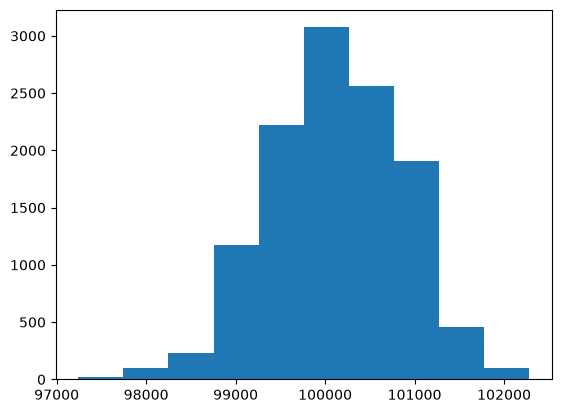

In [7]:
plt.hist(tracks_all.sel(variable="tcmsl").values.flatten())

<>:187: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<>:187: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
/var/folders/4w/jglrh5ks0m93wsr18jhkqvyr0000gn/T/ipykernel_29644/2992079725.py:187: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
  "Hurricane Beryl: NVIDIA HENS-SFNO vs IBTrACS\n(Wind Speed $\geq$ 17 m/s)",


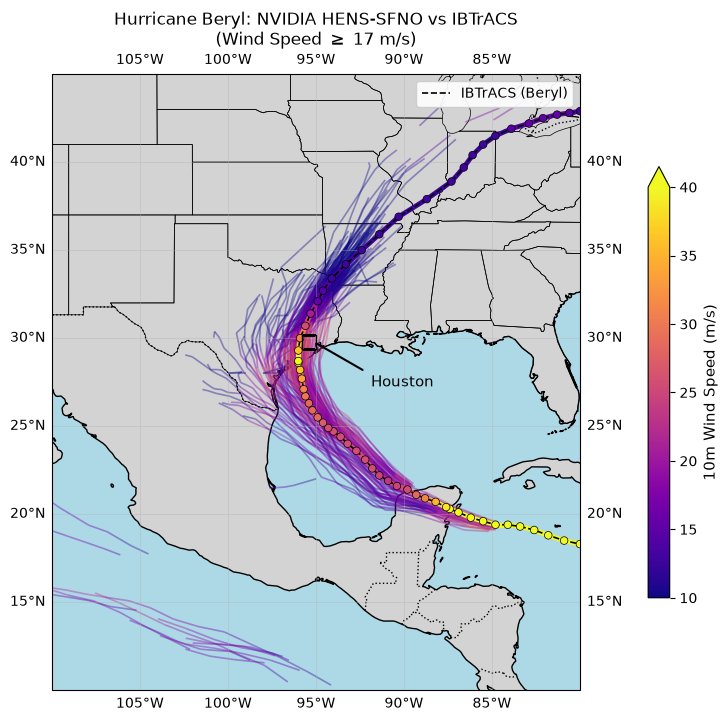

In [79]:
# -------------------------------------------------------------------------
# 1. Process IBTrACS GeoDataFrame for Hurricane Beryl
# -------------------------------------------------------------------------
# Filter Beryl (ensure ISO_TIME is datetime)
beryl_df = gdf[gdf["NAME"].str.upper() == "BERYL"].copy()
beryl_df["ISO_TIME"] = pd.to_datetime(beryl_df["ISO_TIME"])

# Filter for the relevant period matching your forecast window (e.g., July 2024)
beryl_df = beryl_df[
    (beryl_df["ISO_TIME"] >= "2024-07-01")
    & (beryl_df["ISO_TIME"] <= "2024-07-15")
].sort_values("ISO_TIME")

# Use direct numeric LAT/LON coordinates for Cartopy (to bypass metric geometry projection issues)
beryl_lon = beryl_df["LON"].values
beryl_lat = beryl_df["LAT"].values
# Convert knots (USA_WIND) to m/s if necessary (1 knot ≈ 0.514444 m/s)
beryl_wind = beryl_df["USA_WIND"].astype(float).values * 0.514444

# -------------------------------------------------------------------------
# 2. Process Ensemble Tracker Data
# -------------------------------------------------------------------------
lat = tracks_all.sel(variable="tclat").values
lon = tracks_all.sel(variable="tclon").values
wind = tracks_all.sel(variable="tcw10m").values

# Adjust longitudes from [0, 360] to [-180, 180]
lon = np.where(lon > 180, lon - 360, lon)

projection = ccrs.PlateCarree()

fig, ax = plt.subplots(
    figsize=(11, 8),
    subplot_kw={"projection": projection},
)

# Map setup
ax.set_extent([-110, -80, 10, 45], crs=projection)
ax.add_feature(cfeature.LAND, facecolor="lightgrey")
ax.add_feature(cfeature.OCEAN, facecolor="lightblue")
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=":")
ax.add_feature(cfeature.STATES, linewidth=0.5)

# Wind speed colormap bounds
vmin, vmax = 10, 40
norm = Normalize(vmin=vmin, vmax=vmax)
cmap = plt.cm.plasma

ensembles = tracks_all.ensemble.values
times = tracks_all.time.values
paths = tracks_all.path_id.values

# -------------------------------------------------------------------------
# 3. Plot Ensemble Tracks
# -------------------------------------------------------------------------
for ensemble_idx in range(len(ensembles)):
    for time_idx in range(len(times)):
        for path_idx in range(len(paths)):

            x = lon[ensemble_idx, time_idx, path_idx, :]
            y = lat[ensemble_idx, time_idx, path_idx, :]
            w = wind[ensemble_idx, time_idx, path_idx, :]

            # Filter tracks with max wind >= 17 m/s
            if np.all(np.isnan(w)) or np.nanmax(w) < 17.0:
                continue

            valid = ~np.isnan(x) & ~np.isnan(y) & ~np.isnan(w)
            x_v, y_v, w_v = x[valid], y[valid], w[valid]

            if len(x_v) < 2:
                continue

            points = np.array([x_v, y_v]).T.reshape(-1, 1, 2)
            segments = np.concatenate([points[:-1], points[1:]], axis=1)

            lc = LineCollection(
                segments,
                cmap=cmap,
                norm=norm,
                linewidth=1.2,
                alpha=0.4,
                transform=projection,
            )
            lc.set_array(w_v[:-1])
            ax.add_collection(lc)

# -------------------------------------------------------------------------
# 4. Plot IBTrACS Beryl Track On Top
# -------------------------------------------------------------------------
if len(beryl_lon) > 1:
    # Option A: Color-coded track line for Beryl
    valid_b = ~np.isnan(beryl_lon) & ~np.isnan(beryl_lat) & ~np.isnan(beryl_wind)
    bx_v, by_v, bw_v = (
        beryl_lon[valid_b],
        beryl_lat[valid_b],
        beryl_wind[valid_b],
    )

    b_points = np.array([bx_v, by_v]).T.reshape(-1, 1, 2)
    b_segments = np.concatenate([b_points[:-1], b_points[1:]], axis=1)

    lc_beryl = LineCollection(
        b_segments,
        cmap=cmap,
        norm=norm,
        linewidth=3.5,
        zorder=5,
        transform=projection,
    )
    lc_beryl.set_array(bw_v[:-1])
    ax.add_collection(lc_beryl)

    # Option B: High-contrast black dashed outline for clarity
    ax.plot(
        bx_v,
        by_v,
        color="black",
        linestyle="--",
        linewidth=1.2,
        zorder=6,
        transform=projection,
        label="IBTrACS (Beryl)",
    )

    # Scatter points along Beryl's track
    ax.scatter(
        bx_v,
        by_v,
        c=bw_v,
        cmap=cmap,
        norm=norm,
        edgecolor="black",
        linewidth=0.5,
        s=30,
        zorder=7,
        transform=projection,
    )

# -------------------------------------------------------------------------
# 5. Legend, Colorbar & Titles
# -------------------------------------------------------------------------
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, orientation="vertical", shrink=0.7, pad=0.08, extend="max")
cbar.set_label("10m Wind Speed (m/s)", fontsize=11)

# Houston coordinates
houston_lon, houston_lat = -95.37, 29.76

# Draw a square box at Houston's location
ax.plot(
    houston_lon,
    houston_lat,
    marker="s",
    markeredgecolor="k",
    markerfacecolor="none",
    markersize=10,
    markeredgewidth=1.,
    zorder=8,
    transform=projection,
)

# Annotate with a black line pointing from the bottom-right corner of the Houston box
ax.annotate(
    "Houston",
    xy=(houston_lon+.3, houston_lat),  # Point to target coordinates
    xytext=(houston_lon + 3.5, houston_lat - 2.5),  # Text location (offset to lower-right)
    xycoords=projection._as_mpl_transform(ax),  # Geographic coordinates transform
    textcoords=projection._as_mpl_transform(ax),
    fontsize=11,
    # fontweight="bold",
    color="black",
    zorder=9,
    arrowprops=dict(
        arrowstyle="-",            # Simple straight line without arrow head
        color="black",
        linewidth=1.5,
        patchA=None,
        relpos=(0.0, 1.0),         # Connect line to top-left of text
        shrinkA=7,                 # Offset start point to align with bottom-right corner of the marker box
    ),
)

ax.set_title(
    "Hurricane Beryl: NVIDIA HENS-SFNO vs IBTrACS\n(Wind Speed $\geq$ 17 m/s)",
    fontsize=12,
)
ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5)
ax.legend(loc="upper right", framealpha=0.9)

plt.show()